In [1]:
from google.colab import drive
import os
drive.mount('/content/gdrive')
os.chdir("gdrive/MyDrive/Manuscripts/Livingness")

Mounted at /content/gdrive


**Figure 2 plot:** Subjective Ratings of Likability, Livingness, and Complexity

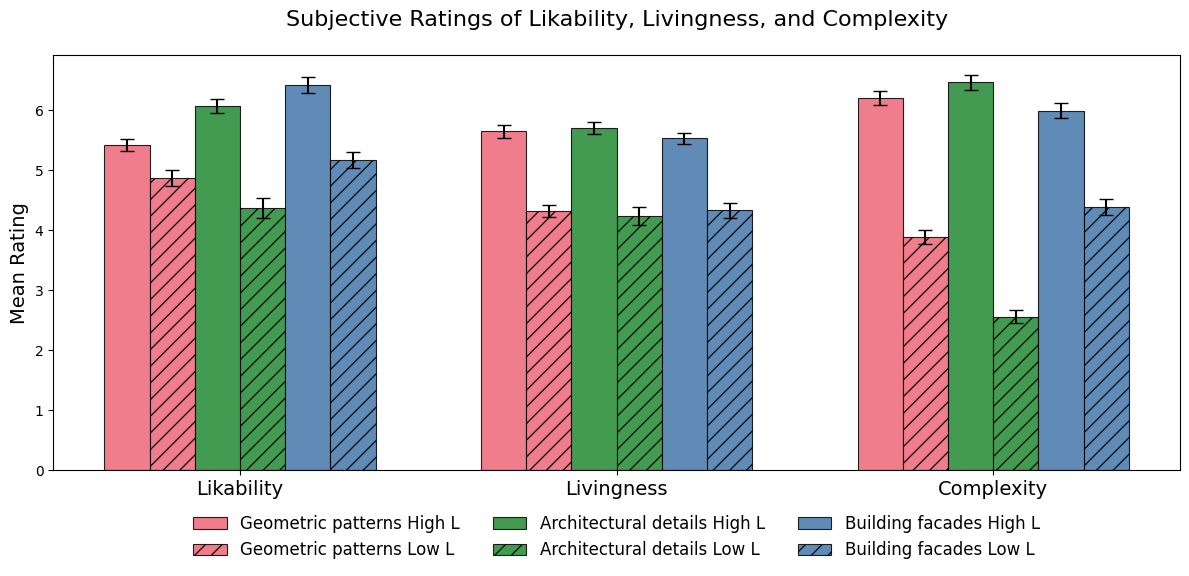

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data as per your table
metrics = ['Likability', 'Livingness', 'Complexity']

group_labels = ['Geometric patterns High L', 'Geometric patterns Low L',
                'Architectural details High L', 'Architectural details Low L',
                'Building facades High L', 'Building facades Low L']

colors = ['#EE6677', '#EE6677',
          '#228833', '#228833',
          '#4477AA', '#4477AA']

# alpha_values = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]  # full saturation; hatch carries High/Low
alpha_values = [0.85, 0.85, 0.85, 0.85, 0.85, 0.85]  # full saturation; hatch carries High/Low

hatch_patterns = ['', '//', '', '//', '', '//']

# Values per metric
likability = [5.41429, 4.86349, 6.06825, 4.37302, 6.4127, 5.17143]
livingness = [5.64762, 4.31429, 5.69841, 4.23175, 5.52698, 4.33333]
complexity = [6.2, 3.88571, 6.46349, 2.56032, 5.99206, 4.38889]
data = [likability, livingness, complexity]

likability_sd = [0.820868, 1.063667, 0.868039, 1.333345, 1.057918, 1.033071]
livingness_sd = [0.846217, 0.782027, 0.779680, 1.175259, 0.708293, 0.983083]
complexity_sd = [0.877864, 0.951206, 0.967421, 0.854691, 1.029297, 1.081085]

likability_sem = [0.103420, 0.134009, 0.109363, 0.167986, 0.133285, 0.130155]
livingness_sem = [0.106613, 0.098526, 0.098230, 0.148069, 0.089237, 0.123857]
complexity_sem = [0.110600, 0.119841, 0.121884, 0.107681, 0.129679, 0.136204]

# error_data = [likability_sd, livingness_sd, complexity_sd]
error_data = [likability_sem, livingness_sem, complexity_sem]

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.12
x = np.arange(len(metrics))

# For each group High L / Low L — plot bars with correct offset
for i in range(len(group_labels)):
    offset = (i - 2.5) * bar_width  # centers bars around each metric
    values = [data[j][i] for j in range(len(metrics))]
    errors = [error_data[j][i] for j in range(len(metrics))]

    ax.bar(x + offset, values, bar_width, yerr=errors, capsize=5,
           color=colors[i], alpha=alpha_values[i],
           edgecolor='black', linewidth=0.8,
           label=group_labels[i], hatch=hatch_patterns[i])

# Labels and formatting
ax.set_ylabel('Mean Rating', fontsize=14)
ax.set_title('Subjective Ratings of Likability, Livingness, and Complexity', fontsize=16, y=1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)

# Legend — deduplicate entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

# Legend below the figure
ax.legend(unique.values(), unique.keys(),
          loc='lower center', bbox_to_anchor=(0.5, -0.25),
          ncol=3, fontsize=12, frameon=False)

# Tight layout
plt.tight_layout()

# Export
plt.savefig('./Figure2_Final.pdf', bbox_inches='tight', facecolor='white')

# 300 DPI PNG
plt.savefig('./Figure2_Final.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

**Figure 3 plot:** Percentage of Participants Preferring High Livingness

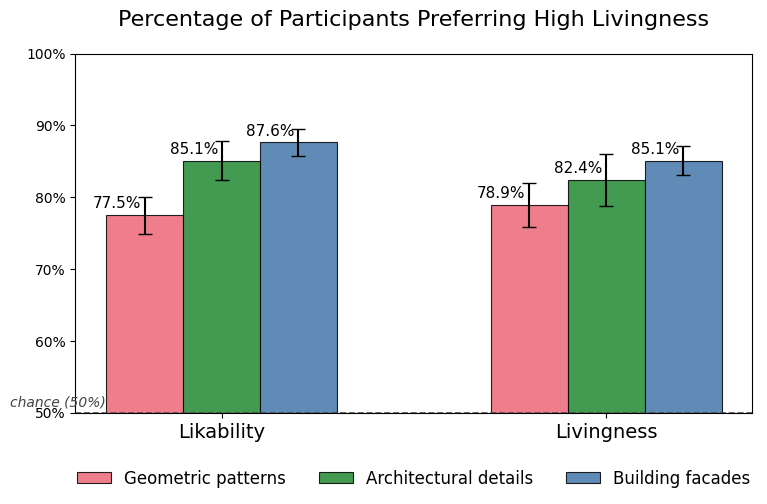

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Data for Figure 3
metrics = ['Likability', 'Livingness']
group_labels = ['Geometric patterns', 'Architectural details', 'Building facades']

# Tol "bright" colorblind-safe palette — SAME as Figure 2
TOL_RED   = '#EE6677'  # Geometric patterns
TOL_GREEN = '#228833'  # Architectural details
TOL_BLUE  = '#4477AA'  # Building facades

colors = {'Geometric patterns':   TOL_RED,
          'Architectural details': TOL_GREEN,
          'Building facades':      TOL_BLUE}
alpha_values = [0.85, 0.85, 0.85, 0.85, 0.85, 0.85]
# alpha_values = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

# Values: per group, per metric
likability = [0.7746, 0.85079, 0.87619]
livingness = [0.78889, 0.82381, 0.85079]
data = [likability, livingness]

likability_sem = [0.025896, 0.027423, 0.018893]
livingness_sem = [0.030536, 0.036114, 0.020349]
error_data = [likability_sem, livingness_sem]

# Bar settings
bar_width = 0.2
x = np.arange(len(metrics))

# Plot setup
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars per group
bars = []  # to collect bar objects for adding labels
for i, group in enumerate(group_labels):
    group_values = [data[j][i] for j in range(len(metrics))]
    group_errors = [error_data[j][i] for j in range(len(metrics))]
    offset = (i - 1) * bar_width  # centers the bars nicely

    bars_group = ax.bar(x + offset, group_values, bar_width,
                        yerr=group_errors, capsize=5,
                        color=colors[group], edgecolor='black', linewidth=0.8,
                        label=group, alpha=alpha_values[i])
    bars.append(bars_group)

# Labels and formatting
ax.set_title('Percentage of Participants Preferring High Livingness',
             fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)

# Y-axis from 0.7 to 0.9 → format as percentage
# ax.set_ylim(0.7, 0.9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='#444444', linestyle='--', linewidth=1.2, alpha=0.9, zorder=1)
ax.text(-0.55, 0.505, 'chance (50%)',
        ha='left', va='bottom',
        fontsize=10, color='#444444', style='italic')

# Add numeric labels on top of each bar
for bars_group in bars:
    for bar in bars_group:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(-20, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

# Legend below the figure
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          loc='lower center', bbox_to_anchor=(0.5, -0.25),
          ncol=3, fontsize=12, frameon=False)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0.1, 1, 1])

# --- Export ---
# Vector PDF (best for print, scalable, small file)
plt.savefig('Figure3_Final.pdf', bbox_inches='tight', facecolor='white')

# 300 DPI PNG (raster, for portals that prefer images)
plt.savefig('Figure3_Final.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

**Figure 4 plot:** Aesthetic Emotions in Response to High vs. Low Livingness Images

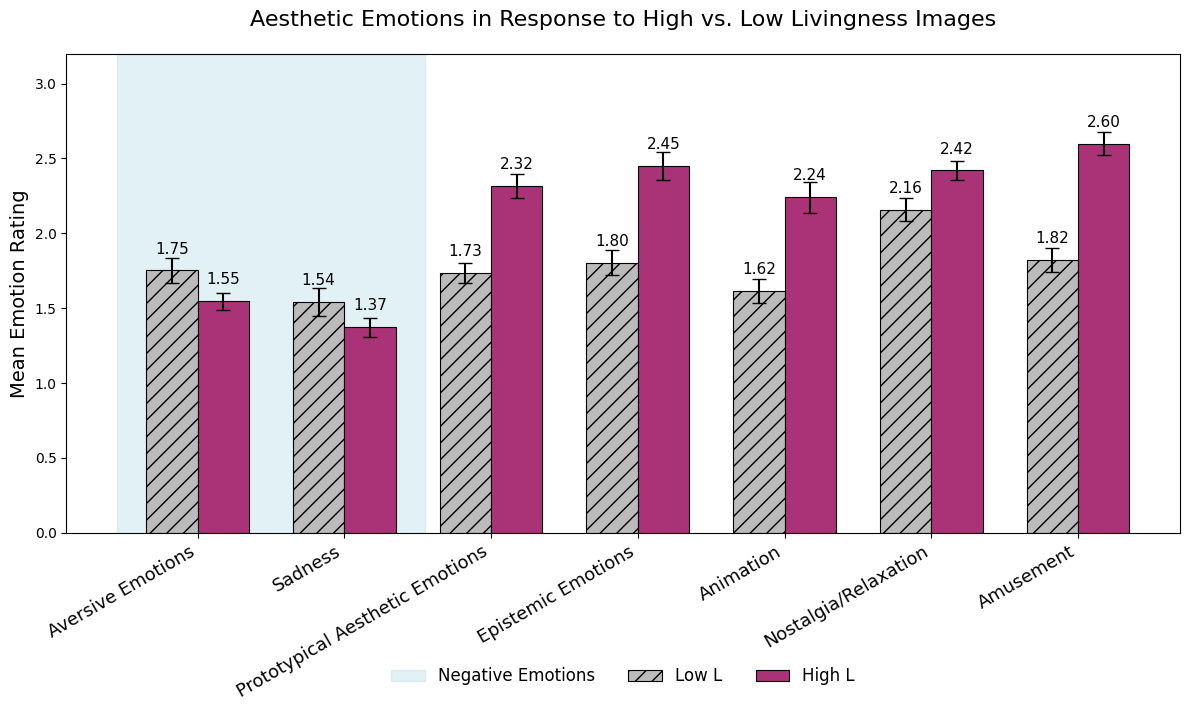

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Emotion categories
categories = [
    "Aversive Emotions", "Sadness", "Prototypical Aesthetic Emotions",
    "Epistemic Emotions", "Animation", "Nostalgia/Relaxation", "Amusement"
]

# Mean emotion ratings
high_l  = [1.54603, 1.37302, 2.31746, 2.45238, 2.24074, 2.42063, 2.59921]
low_l = [1.75238, 1.53968, 1.73333, 1.80423, 1.61640, 2.15873, 1.82143]

# SEM values
sem_high_l  = [0.056562, 0.063970, 0.080148, 0.093635, 0.102715, 0.065197, 0.077421]
sem_low_l = [0.082643, 0.092126, 0.065270, 0.085047, 0.080414, 0.077421, 0.077421]

# Tol "bright" colorblind-safe palette — consistent with Figures 2 and 3
TOL_BLUE = '#4477AA'   # High L
TOL_GREY = '#BBBBBB'   # Low L (Tol's neutral grey)

TOL_PURPLE = '#AA3377'


# Bar positions
x = np.arange(len(categories))
width = 0.35

# Plot setup
fig, ax = plt.subplots(figsize=(12, 8))

# IMPORTANT: bars1 and bars2 labels were swapped in the original code.
# bars1 (left bar, x - width/2) plotted high_l but was labelled 'Low L'.
# Fixed below: left bar = High L (colored), right bar = Low L (grey).
bars1 = ax.bar(x - width/2, low_l, width,
               label='Low L',
               color=TOL_GREY, edgecolor='black', linewidth=0.8, hatch='//',
               yerr=sem_low_l, capsize=5, alpha=1)

bars2 = ax.bar(x + width/2, high_l, width,
               label='High L',
               color=TOL_PURPLE, edgecolor='black', linewidth=0.8,
               yerr=sem_high_l, capsize=5, alpha=1)

# Highlight aversive/sadness categories (negative emotions)
highlight_indices = [0, 1]
x_start = x[highlight_indices[0]] - width
x_end = x[highlight_indices[-1]] + width
ax.axvspan(x_start - 0.2, x_end + 0.2,
           color='lightblue', alpha=0.35, zorder=0,
           label='Negative Emotions')

# Axis labels and ticks
ax.set_ylabel('Mean Emotion Rating', fontsize=14)
ax.set_title('Aesthetic Emotions in Response to High vs. Low Livingness Images',
             fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right', fontsize=13)
ax.set_ylim(0, 3.2)

# Add data labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

# Legend (centered below the plot)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35),
          ncol=3, frameon=False, fontsize=12)

# Layout and save
plt.tight_layout(rect=[0, 0.05, 1, 1])

# --- Export ---
plt.savefig('Figure4_Final.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('Figure4_Final.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

**High vs. Low livingness**

In [35]:
import pandas as pd

# Load the uploaded CSV files
likability_df = pd.read_csv("likability.csv")
livingness_df = pd.read_csv("livingness.csv")

# Display first few rows of each to understand their structure
likability_df.head()
livingness_df.head()

,Connectedness to Nature,High L,Low L,High vs. Low L
0,4.000,5.600,3.900,1.700
1,4.071,6.133,4.600,1.533
2,3.929,6.033,4.067,1.967
3,3.929,6.400,3.700,2.700
4,3.000,5.433,3.867,1.567


**Figure 5 plot:** Relationship between Connectedness to Nature and Subjective Ratings

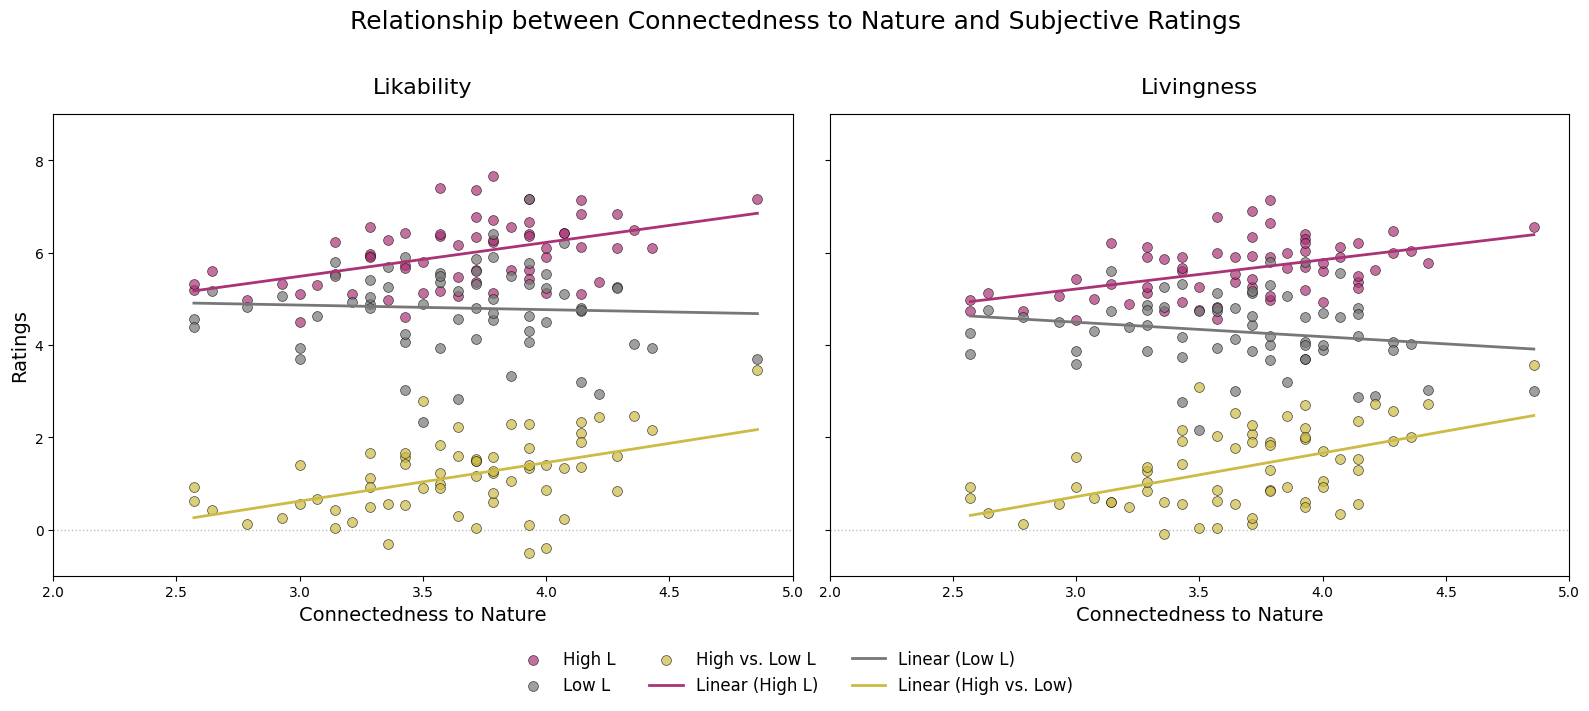

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Re-load the uploaded CSV files
likability_df = pd.read_csv("likability.csv")
livingness_df = pd.read_csv("livingness.csv")

# Extract data
cn_like  = likability_df["Connectedness to Nature"]
high_l_like = likability_df["High L"]
low_l_like  = likability_df["Low L"]
diff_like   = likability_df["High vs. Low L"]

cn_live  = livingness_df["Connectedness to Nature"]
high_l_live = livingness_df["High L"]
low_l_live  = livingness_df["Low L"]
diff_live   = livingness_df["High vs. Low L"]

# Tol "bright" colorblind-safe palette — consistent with previous figures
TOL_PURPLE = '#AA3377'   # High L  (matches Figure 4 "High L" purple)
TOL_GREY   = '#777777'   # Low L   (slightly darker than Figure 4's bar grey for scatter visibility)
TOL_YELLOW = '#CCBB44'   # Difference

# Prepare side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
ax1.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=0)
ax2.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=0)

def plot_panel(ax, cn, high_l, low_l, diff, title, show_legend_labels=True):
    """Helper to plot one panel."""
    # Scatter points
    ax.scatter(cn, high_l, color=TOL_PURPLE, s=50, alpha=0.7,
               edgecolor='black', linewidth=0.5,
               label='High L' if show_legend_labels else None)
    ax.scatter(cn, low_l,  color=TOL_GREY,   s=50, alpha=0.7,
               edgecolor='black', linewidth=0.5,
               label='Low L' if show_legend_labels else None)
    ax.scatter(cn, diff,   color=TOL_YELLOW, s=50, alpha=0.7,
               edgecolor='black', linewidth=0.5,
               label='High vs. Low L' if show_legend_labels else None)

    # Regression lines
    x_vals = np.linspace(cn.min(), cn.max(), 100)
    for y, color, lbl in [(high_l, TOL_PURPLE, 'Linear (High L)'),
                          (low_l,  TOL_GREY,   'Linear (Low L)'),
                          (diff,   TOL_YELLOW, 'Linear (High vs. Low)')]:
        reg = linregress(cn, y)
        ax.plot(x_vals, reg.intercept + reg.slope * x_vals,
                color=color, linewidth=2,
                label=lbl if show_legend_labels else None)

    ax.set_xlabel('Connectedness to Nature', fontsize=14)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlim(2, 5)


# Plot both panels
plot_panel(ax1, cn_like, high_l_like, low_l_like, diff_like,
           'Likability', show_legend_labels=True)
plot_panel(ax2, cn_live, high_l_live, low_l_live, diff_live,
           'Livingness', show_legend_labels=False)

ax1.set_ylabel('Ratings', fontsize=14)
ax1.set_ylim(-1, 9)

# Shared legend below the figure
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=3, fontsize=12, frameon=False)

# Suptitle
plt.suptitle('Relationship between Connectedness to Nature and Subjective Ratings',
             fontsize=18)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])

# --- Export ---
plt.savefig('Figure5_Final.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('Figure5_Final.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()